# Notebook for quick set-up of simulation in development mode

In [1]:
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd
import shutil

from config import get_config, get_development_config, setup_dev_directories, get_simulation_params, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_optimized, analyze_simulation_performance
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
import src.grid_based_accessibility_hex as grid_hex

In [2]:
config = get_development_config()
setup_dev_directories(config, remove_cache=True)
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['ls', 'msls'])
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  

# Configure simulation parameters from config
simulation_params = get_simulation_params(config) 


Created directories: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps, c:\repos\powerpath\data\output\output_test_hazard_timesteps
Found 2 electricity station files matching types ['ls', 'msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp']
Loading electricity assets from ls_stations_test_samples.shp
Loaded 36 ls assets
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 281 electricity assets
Asset types: {'msls': 245, 'ls': 36}
Found 10 hazard map files


In [3]:
accessibility_model = None
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")


Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  damage_ratio_coefficients: (0.0468, 0.0077)
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_threshold: 0.01
  repair_threshold: 2.0
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps


In [4]:
config['simulation_config']['major_timestep'] = 24
config['simulation_config']['verbose'] = False
max_days = None


performance_data, results, total_time = analyze_simulation_performance(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps[:max_days],
    config=config, 
    max_maps=None)


Starting performance analysis (max None maps)
Baseline memory: 279.3 MB
Using hazard directory for cache naming: test_hazard_timesteps

Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\cache\hazard_extraction_cache_test_hazard_timesteps.pkl
No island cache found at c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\cache\island_cache_test_hazard_timesteps.pkl


Simulation Iterations:   0%|          | 0/10 [00:00<?, ?it/s]

Extracting hazard values using method: max
Saved hazard extraction cache: 1 entries to c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\cache\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction results for map 0 from GHG_timesteps_test0.tif
Cache miss for 0.2_EV0_ma, computing islands on the fly...
>>>>Total processing time: 2.16 seconds
Successfully computed and cached islands for 0.2_EV0_ma
Extracting hazard values using method: max
Saved hazard extraction cache: 2 entries to c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\cache\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction results for map 1 from GHG_timesteps_test1.tif
Cache miss for 0.2_EV1_ma, computing islands on the fly...
  Using spatial index for 16 unassigned assets...
>>>>Total processing time: 1.83 seconds
Successfully computed and cached islands for 0.2_EV1_ma
Overlap computation complete.
Saved overlap cache: 1 entries to c:\repos\powerpath\dat

Simulation Iterations:  30%|███       | 3/10 [00:36<01:06,  9.56s/it]

Saved updated island cache with 10 entries to c:\repos\powerpath\data\interim\interim_test_hazard_timesteps\cache\island_cache_test_hazard_timesteps.pkl


Simulation Iterations: 100%|██████████| 10/10 [00:37<00:00,  3.74s/it]

Saved simulation configuration to c:\repos\powerpath\data\output\output_test_hazard_timesteps\log_config.txt

PERFORMANCE REPORT
Total simulation time: 37.38s
Memory usage: 279.3 MB → 372.7 MB (Δ+93.3 MB)
Timesteps processed: 10

FUNCTION PERFORMANCE:
  compute_island_geodataframe_from_graph:
    Calls: 10
    Total time: 3.935s (10.5% of simulation)
    Average per call: 0.394s
    Min/Max: 0.372s / 0.455s
  update_hazard_map_states:
    Calls: 100
    Total time: 36.959s (98.9% of simulation)
    Average per call: 0.370s
    Min/Max: 0.003s / 4.209s
  crew_assignment:
    Calls: 2400
    Total time: 0.053s (0.1% of simulation)
    Average per call: 0.000s
    Min/Max: 0.000s / 0.001s
  create_spatial_index:
    Calls: 18
    Total time: 0.030s (0.1% of simulation)
    Average per call: 0.002s
    Min/Max: 0.001s / 0.004s

Percentage of total time spent in key functions:
  compute_island_geodataframe_from_graph: 10.5%
  update_hazard_map_states: 98.9%
  crew_assignment: 0.1%
  create_

In [5]:
results_df_x=pd.DataFrame(results[0][1])
print_simulation_summary(results_df_x, gdf_assets, config)

SIMULATION RESULTS SUMMARY
Total assets: 281
Simulation duration: 240 hours (10 days)
Final operational rate: 100.0%
Peak damaged assets: 11
Peak flooded assets: 11
Total crew assignments: 150

RECOVERY TIMELINE (Daily Summary)
Day 0: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 1: 97.2% operational, 10 flooded, 0 unreachable, 10 damaged.
Day 2: 96.8% operational, 11 flooded, 0 unreachable, 11 damaged.
Day 3: 96.4% operational, 10 flooded, 1 unreachable, 11 damaged.
Day 4: 97.5% operational, 7 flooded, 0 unreachable, 7 damaged.
Day 5: 97.5% operational, 7 flooded, 0 unreachable, 7 damaged.
Day 6: 98.9% operational, 0 flooded, 0 unreachable, 3 damaged.
Day 7: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 8: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 9: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.

REPAIR BACKLOG ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
---------------------------------------------------

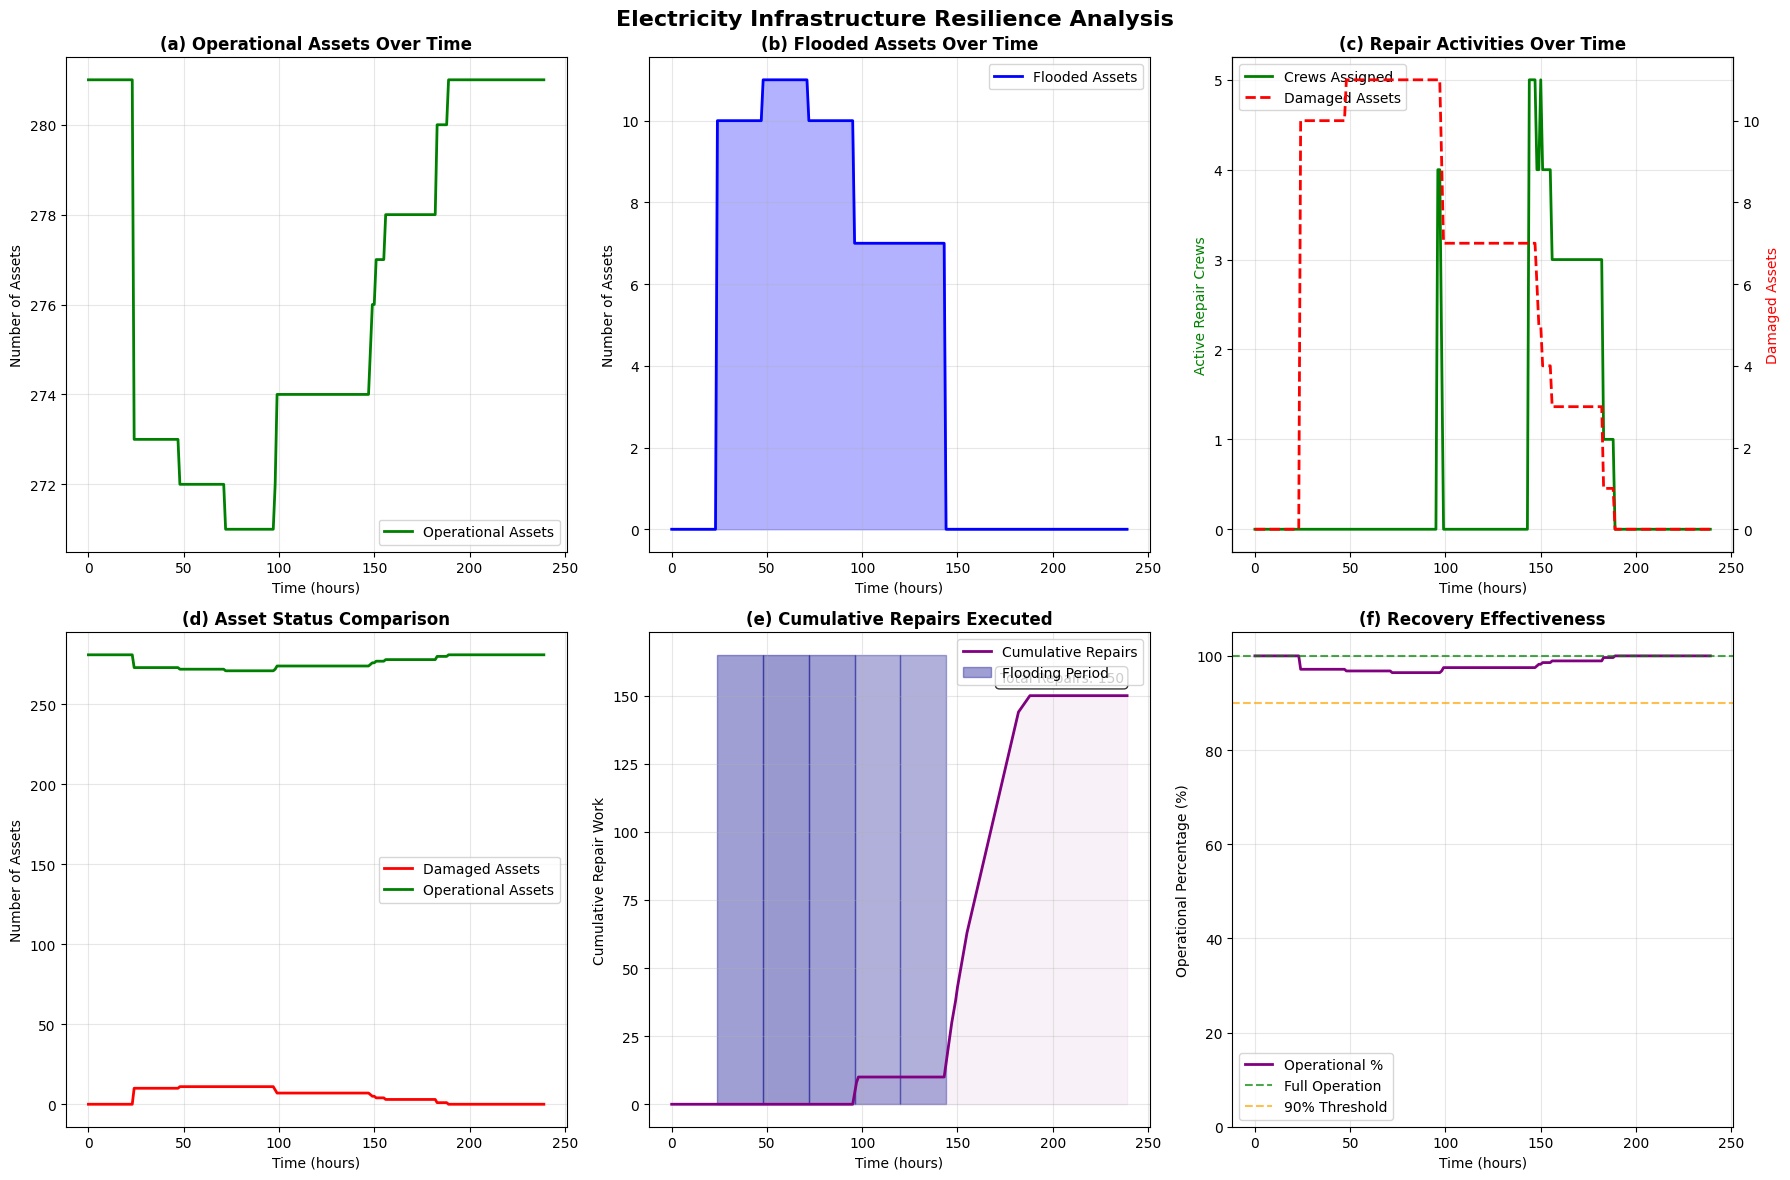

In [6]:
# Show comprehensive visualization
fig = create_comprehensive_visualization(results_df_x, gdf_assets, config)
plt.show()

In [7]:
import pickle
import networkx as nx
from src.utils import project_graph_coords, filter_hazard_graph
from pyproj import Transformer
from shapely.geometry import LineString


def compute_island_geodataframe_from_graph(graph_pickle_path: str, hazard_threshold: float, hazard_column: str, buffer_distance: float = 2.5) -> gpd.GeoDataFrame:
    """
    Create GeoDataFrame from graph with buffered road geometries for spatial operations.
    Deduplicates before buffering for efficiency.
    """
    with open(graph_pickle_path, "rb") as f:
        G = pickle.load(f)
        # G = nx.DiGraph(G)

    G = project_graph_coords(G, from_crs="EPSG:4326", to_crs="EPSG:28992")
    G = filter_hazard_graph(G, hazard_threshold, hazard_column)

    # Identify strongly connected components
    if G.is_directed():
        components = list(nx.strongly_connected_components(G))
    else:
        components = list(nx.connected_components(G))
    
    fid_to_island = {}

    # Assign island_id to each fid
    for i, comp in enumerate(components):
        subgraph = G.subgraph(comp)
        for u, v, data in subgraph.edges(data=True):
            fid_to_island[u] = i
            fid_to_island[v] = i

    # Create transformer for projecting geometries
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
    
    # Build edge records with geometry and length (NO BUFFERING YET)
    records = []

    for u, v, data in G.edges(data=True):
        # Project the actual edge geometry
        original_geom = data['geometry']
        if hasattr(original_geom, 'coords'):
            # Project all coordinates in the geometry
            projected_coords = [transformer.transform(x, y) for x, y in original_geom.coords]
            projected_geom = LineString(projected_coords)
        else:
            # Fallback: create LineString from node positions if no edge geometry
            projected_geom = LineString([(G.nodes[u]["x_m"], G.nodes[u]["y_m"]),
                                       (G.nodes[v]["x_m"], G.nodes[v]["y_m"])])
        
        length_m = data.get("length", None)
        if length_m is None:
            print(f"Length not found for edge ({u}, {v}), calculating from projected geometry.")
            length_m = projected_geom.length  # Use original linestring for length calculation

        island_id = fid_to_island.get(v, -1)

        record = data.copy()
        record["geometry"] = projected_geom  # Keep original linestring geometry for now
        record["length_m"] = length_m
        record["island_id"] = island_id
        records.append(record)

    # Create initial GeoDataFrame with linestring geometries
    gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:28992")

    # Deduplication and buffering
    print(f"Before deduplication: {len(gdf)} road segments")
    gdf = gdf.drop_duplicates(subset=["geometry", "island_id"])
    print(f"After deduplication: {len(gdf)} road segments")
    print(f'dropped a total of {len(records) - len(gdf)} duplicate road segments')

    buffered_geometries = []
    original_geometries = []
    
    for _, row in gdf.iterrows():
        original_geom = row.geometry
        
        # Buffer the linestring to create a polygon for spatial operations
        try:
            buffered_geom = original_geom.buffer(buffer_distance, cap_style='square', join_style='mitre')
            if buffered_geom.is_empty or not buffered_geom.is_valid:
                buffered_geom = original_geom.make_valid().buffer(buffer_distance, cap_style='square', join_style='mitre')
        except Exception as e:
            print(f"Warning: Error buffering geometry: {e}, using original")
            buffered_geom = original_geom
        
        buffered_geometries.append(buffered_geom)
        original_geometries.append(original_geom)
    
    # Update geometries
    gdf['original_geometry'] = original_geometries
    gdf['geometry'] = buffered_geometries  # Replace with buffered geometries
    
    print(f"Buffered {len(gdf)} road segments with {buffer_distance}m buffer")

    # Compute island sizes using original linestring lengths (more accurate for road network analysis)
    island_sizes = gdf.groupby("island_id")["length_m"].sum().reset_index()
    island_sizes["island_size_km"] = island_sizes["length_m"] / 1000.0
    island_sizes = island_sizes[["island_id", "island_size_km"]]

    # Merge island sizes back into GeoDataFrame
    gdf = gdf.merge(island_sizes, on="island_id", how="left")
    gdf["island_size_km"] = gdf["island_size_km"].fillna(0.0)

    print(f"Island distribution: {gdf['island_id'].value_counts().sort_index().to_dict()}")
    return gdf

hazard_graph_path = r'C:\repos\powerpath\data\test_samples\static\output_graph\base_graph_hazard_editted.p'
hazard_threshold = 0.2
hazard_column = 'EV2_ma'

islands_gdf = compute_island_geodataframe_from_graph(
    hazard_graph_path, hazard_threshold=hazard_threshold, 
    hazard_column=hazard_column, buffer_distance=20
)

Before deduplication: 963 road segments
After deduplication: 963 road segments
dropped a total of 0 duplicate road segments
Buffered 963 road segments with 20m buffer
Island distribution: {0: 24, 1: 2, 2: 842, 3: 81, 4: 1, 5: 1, 6: 5, 7: 1, 8: 1, 9: 1, 10: 2, 11: 2}


0      24
1       2
2     842
3      81
4       1
5       1
6       5
7       1
8       1
9       1
10      2
11      2
Name: island_id, dtype: int64

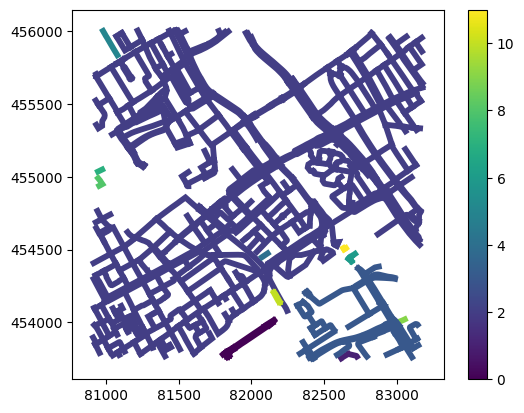

In [8]:
islands_gdf.plot(column='island_id', legend=True, lw=0)
islands_gdf.island_id.value_counts().sort_index()

In [9]:
graph_pickle_path = r'C:\repos\powerpath\data\test_samples\static\output_graph\base_graph_hazard_editted.p'
import pickle
with open(graph_pickle_path, "rb") as f:
        G = pickle.load(f)
G.edges.head()

AttributeError: 'MultiEdgeView' object has no attribute 'head'